# Day 11 — Gradient Descent from Scratch

**365 Days of AI/ML with Akshay**

This notebook is designed for beginners. We will first understand gradient descent on a tiny mathematical function, then use the same idea to train a linear regression model **without using scikit-learn for training**.

### Mental model

Imagine standing on a foggy hill and trying to reach the lowest point.

1. Check which direction slopes upward.
2. Move a small step in the opposite direction.
3. Repeat until you are close to the bottom.

That repeated update is gradient descent.

For a parameter \(\theta\):

\[
\theta_{new} = \theta_{old} - \alpha \frac{dJ}{d\theta}
\]

where:

- \(J\) = loss/cost function
- gradient = slope of the loss
- \(\alpha\) = learning rate (step size)


## Part 1 — Gradient descent with just one number

Let's minimize:

\[
J(w) = (w - 3)^2
\]

The minimum is obviously at \(w=3\), but we will pretend we do not know that.

Its derivative is:

\[
\frac{dJ}{dw} = 2(w-3)
\]

We start at \(w=-4\), calculate the slope, and repeatedly move against it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def cost(w):
    return (w - 3) ** 2

def gradient(w):
    return 2 * (w - 3)

w = -4.0
learning_rate = 0.1
history_w = [w]
history_cost = [cost(w)]

for step in range(20):
    grad = gradient(w)
    w = w - learning_rate * grad

    history_w.append(w)
    history_cost.append(cost(w))

    if step < 5 or step in [9, 19]:
        print(
            f"Step {step + 1:2d}: "
            f"gradient={grad:8.4f}, w={w:8.4f}, cost={cost(w):10.6f}"
        )

print(f"\nFinal w ≈ {w:.4f}")
print("True minimum = 3")


Step  1: gradient=-14.0000, w= -2.6000, cost= 31.360000
Step  2: gradient=-11.2000, w= -1.4800, cost= 20.070400
Step  3: gradient= -8.9600, w= -0.5840, cost= 12.845056
Step  4: gradient= -7.1680, w=  0.1328, cost=  8.220836
Step  5: gradient= -5.7344, w=  0.7062, cost=  5.261335
Step 10: gradient= -1.8790, w=  2.2484, cost=  0.564932
Step 20: gradient= -0.2018, w=  2.9193, cost=  0.006513

Final w ≈ 2.9193
True minimum = 3


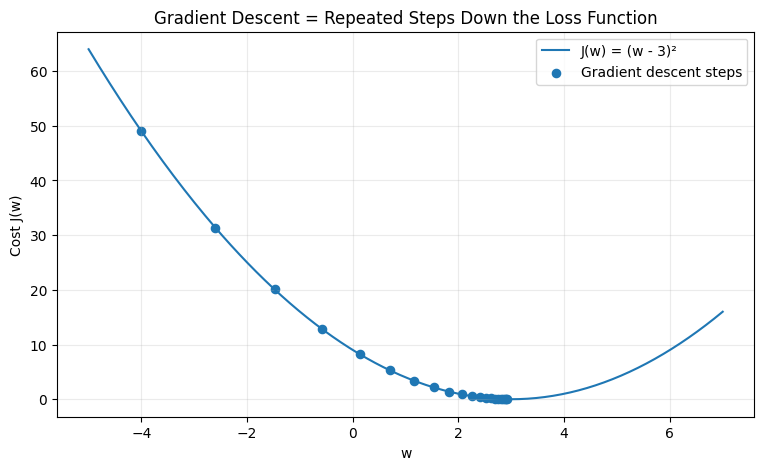

In [2]:
w_space = np.linspace(-5, 7, 300)

plt.figure(figsize=(9, 5))
plt.plot(w_space, cost(w_space), label="J(w) = (w - 3)²")
plt.scatter(history_w, history_cost, s=35, label="Gradient descent steps")
plt.xlabel("w")
plt.ylabel("Cost J(w)")
plt.title("Gradient Descent = Repeated Steps Down the Loss Function")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### What happened?

When \(w < 3\), the gradient is negative. Subtracting a negative number moves \(w\) to the right.

When \(w > 3\), the gradient is positive. Subtracting it moves \(w\) to the left.

So the gradient tells us **which direction increases the loss**, and gradient descent moves in the opposite direction.


## Part 2 — Train a line using gradient descent

Now let's create data that roughly follows:

\[
y = 4 + 3x + noise
\]

Our model will be:

\[
\hat{y} = wx + b
\]

The goal is to discover good values for **w** and **b** by minimizing Mean Squared Error (MSE):

\[
MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2
\]


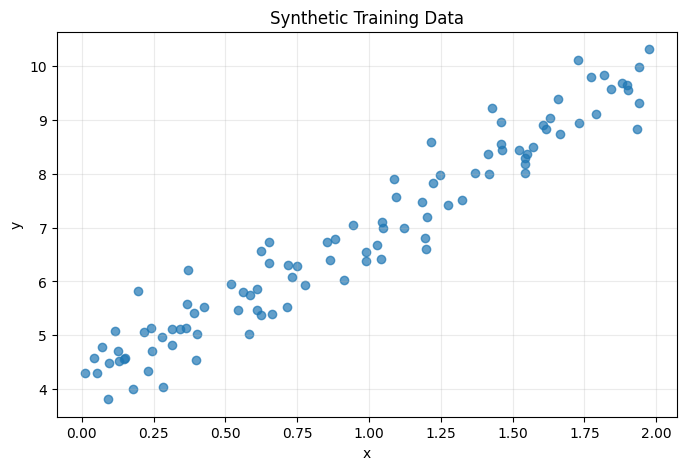

In [3]:
np.random.seed(42)

X = 2 * np.random.rand(100)
noise = np.random.randn(100) * 0.5
y = 4 + 3 * X + noise

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Training Data")
plt.grid(alpha=0.25)
plt.show()


### The gradients for linear regression

For predictions \(\hat y = wx+b\):

\[
\frac{\partial MSE}{\partial w}
= \frac{2}{n}\sum(\hat y-y)x
\]

\[
\frac{\partial MSE}{\partial b}
= \frac{2}{n}\sum(\hat y-y)
\]

We calculate these two slopes and update both parameters.


In [4]:
def train_linear_regression_gd(X, y, learning_rate=0.1, epochs=100):
    w = 0.0
    b = 0.0
    n = len(X)

    losses = []
    w_history = []
    b_history = []

    for epoch in range(epochs):
        y_pred = w * X + b
        error = y_pred - y

        loss = np.mean(error ** 2)

        dw = (2 / n) * np.sum(error * X)
        db = (2 / n) * np.sum(error)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        losses.append(loss)
        w_history.append(w)
        b_history.append(b)

    return w, b, losses, w_history, b_history

w, b, losses, w_history, b_history = train_linear_regression_gd(
    X, y, learning_rate=0.1, epochs=100
)

print(f"Learned weight (w): {w:.4f}  | expected around 3")
print(f"Learned bias   (b): {b:.4f}  | expected around 4")
print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss:   {losses[-1]:.4f}")


Learned weight (w): 2.9096  | expected around 3
Learned bias   (b): 4.0798  | expected around 4
Initial loss: 49.6385
Final loss:   0.2019


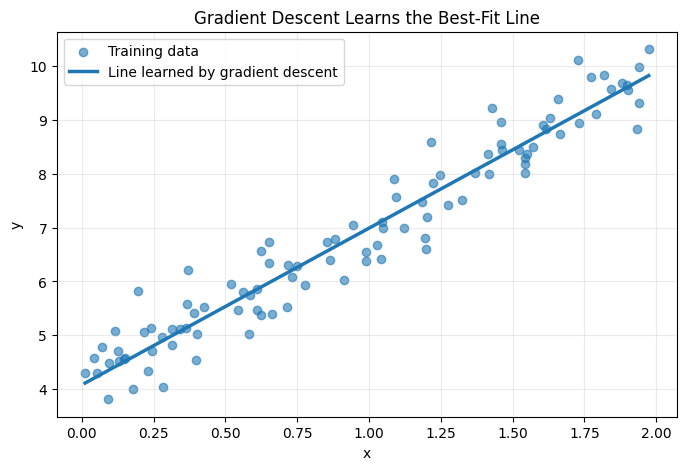

In [5]:
x_line = np.linspace(X.min(), X.max(), 100)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, label="Training data")
plt.plot(x_line, w * x_line + b, linewidth=2.5, label="Line learned by gradient descent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent Learns the Best-Fit Line")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


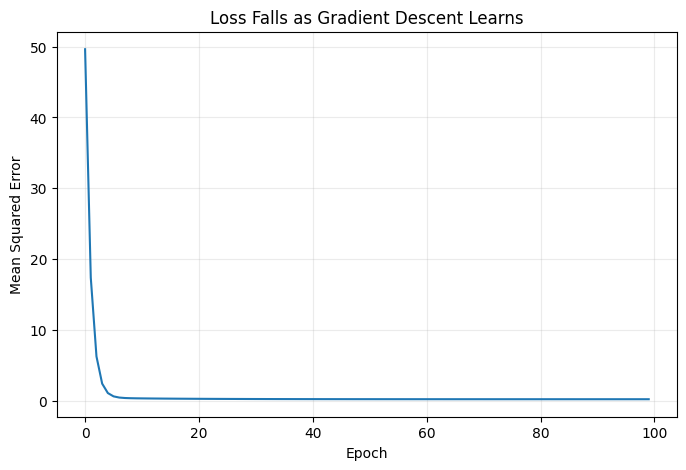

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Loss Falls as Gradient Descent Learns")
plt.grid(alpha=0.25)
plt.show()


## Part 3 — Why the learning rate matters

The learning rate controls the size of each update.

- **Too small:** learning works, but slowly.
- **Reasonable:** reaches a low loss efficiently.
- **Too large:** may overshoot the minimum and become unstable.

Run the next cell and compare the loss curves.


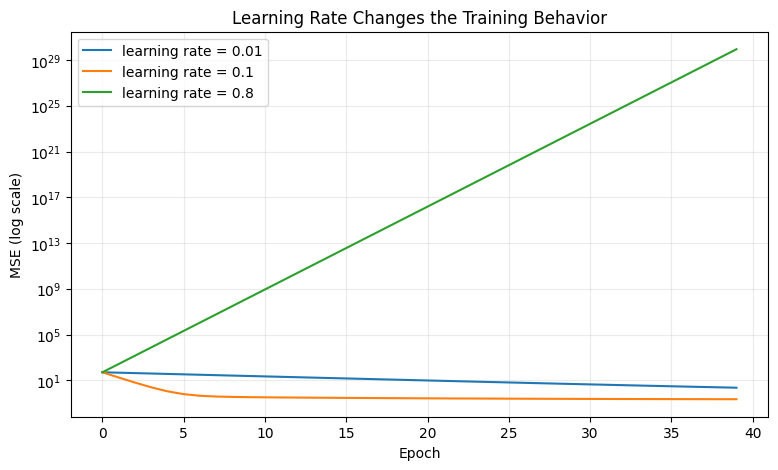

In [7]:
learning_rates = [0.01, 0.1, 0.8]

plt.figure(figsize=(9, 5))

for lr in learning_rates:
    _, _, lr_losses, _, _ = train_linear_regression_gd(
        X, y, learning_rate=lr, epochs=40
    )
    plt.plot(lr_losses, label=f"learning rate = {lr}")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Learning Rate Changes the Training Behavior")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Part 4 — See the optimization path in parameter space

A linear regression model has two parameters here: \(w\) and \(b\).

Every point on the contour plot below represents one possible pair \((w,b)\). The color contours represent different loss levels, and the dots show how gradient descent travels toward a low-loss region.


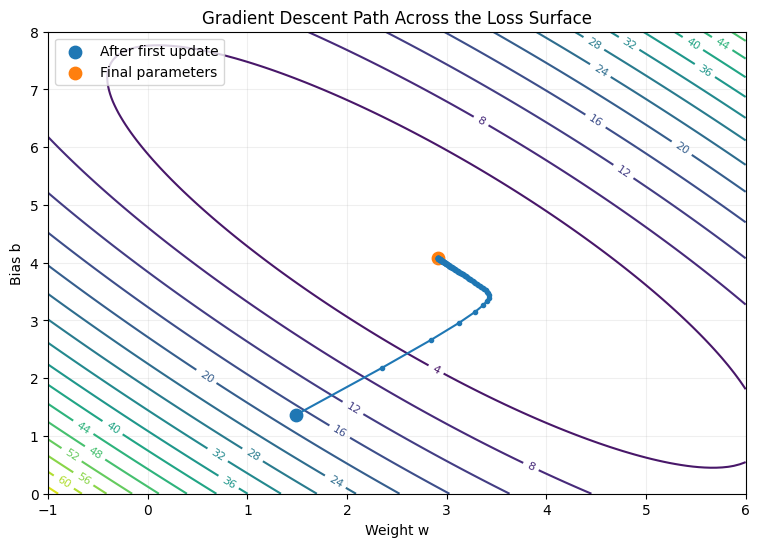

In [8]:
w_values = np.linspace(-1, 6, 120)
b_values = np.linspace(0, 8, 120)
W, B = np.meshgrid(w_values, b_values)

Z = np.empty_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        pred = W[i, j] * X + B[i, j]
        Z[i, j] = np.mean((pred - y) ** 2)

plt.figure(figsize=(9, 6))
contours = plt.contour(W, B, Z, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(w_history, b_history, marker="o", markersize=3, linewidth=1.5)
plt.scatter([w_history[0]], [b_history[0]], s=80, label="After first update")
plt.scatter([w_history[-1]], [b_history[-1]], s=80, label="Final parameters")

plt.xlabel("Weight w")
plt.ylabel("Bias b")
plt.title("Gradient Descent Path Across the Loss Surface")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Part 5 — Tiny experiment for you

Change only this value:

```python
learning_rate = 0.1
```

Try:

- `0.001`
- `0.01`
- `0.1`
- `0.8`
- `1.5`

Then observe:

1. Does the loss decrease?
2. How quickly?
3. Does it oscillate or explode?

That experiment is more useful than memorizing the update equation.


## Key takeaways

**Gradient descent is an optimization algorithm.**

It repeatedly:

1. makes predictions,
2. measures the loss,
3. calculates how the parameters affect that loss,
4. moves the parameters in the opposite direction of the gradient,
5. repeats.

The learning rate controls **how big each move is**.

This same basic optimization idea appears throughout machine learning and deep learning, although real systems may use variants such as stochastic gradient descent, mini-batches, momentum, Adam, and other optimizers.

### Further reading

- Google Machine Learning Crash Course — *Linear regression: Gradient descent*
- Google Machine Learning Crash Course — *Linear regression: Hyperparameters*
- Stanford CS231n — *Loss Functions and Optimization*
- scikit-learn documentation — *SGDRegressor*
